<a href="https://colab.research.google.com/github/KarineMuradyan/University_OptimizationMethods/blob/main/lab1%E2%80%94Personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Accurate Solution (using SciPy) ---
Exact Minimum Point (x*): 1.1572
Exact Minimum Value f(x*): -0.6609

--- Sampling Method Calculations (n=6) ---
x0 = 0.0, f(x0) = 1.00
x1 = 0.5, f(x1) = -0.14
x2 = 1.0, f(x2) = -0.63
x3 = 1.5, f(x3) = -0.53
x4 = 2.0, f(x4) = 0.14
x5 = 2.5, f(x5) = 1.33
x6 = 3.0, f(x6) = 3.05

--- Approximate Results ---
Approximate x_min (Sampling): 1.0
Approximate y_min (Sampling): -0.6321205588285577

--- Accuracy Verification ---
Absolute Error (epsilon = |x* - x_min|): 0.1572
Verification: epsilon (0.1572) <= h (0.5) -> Condition Met (True)


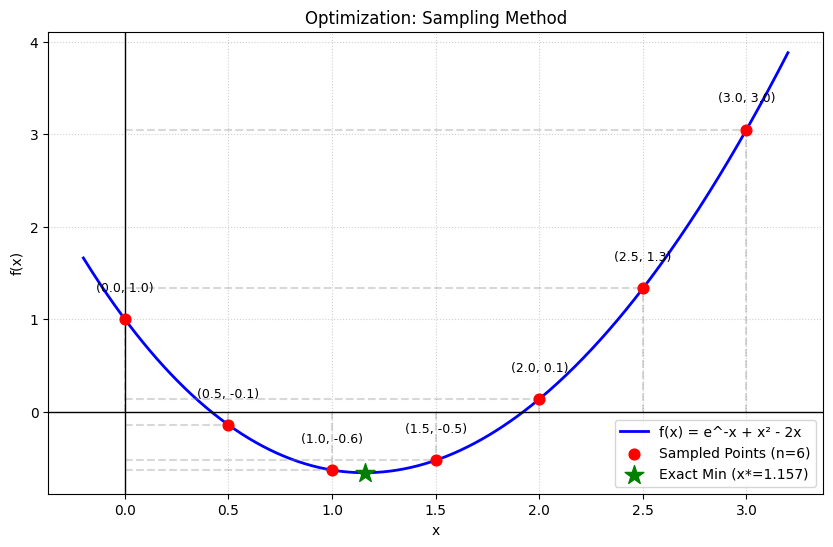

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def f(x):
    return np.e**(-x)+x**2-2*x

# 1. Accurate Solution (using SciPy)
res = minimize(f, x0=1.5)
x_star = res.x[0]
f_star = res.fun

print("--- Accurate Solution (using SciPy) ---")
print(f"Exact Minimum Point (x*): {x_star:.4f}")
print(f"Exact Minimum Value f(x*): {f_star:.4f}")

# 2. Sampling Method
a, b = 0, 3
n = 6
h = (b - a) / n
x_points = []
y_points = []

print("\n--- Sampling Method Calculations (n=6) ---")
for k in range(n + 1):
    xk = a + k * h
    yk = f(xk)
    x_points.append(xk)
    y_points.append(yk)
    print(f"x{k} = {xk:.1f}, f(x{k}) = {yk:.2f}")

# Find the approximate minimum from the sampled points
f_min_approx = min(y_points)
x_min_approx = x_points[y_points.index(f_min_approx)]

print("\n--- Approximate Results ---")
print(f"Approximate x_min (Sampling): {x_min_approx}")
print(f"Approximate y_min (Sampling): {f_min_approx}")

# 3. Accuracy Check
epsilon = abs(x_star - x_min_approx)
print("\n--- Accuracy Verification ---")
print(f"Absolute Error (epsilon = |x* - x_min|): {epsilon:.4f}")
if epsilon <= h:
    print(f"Verification: epsilon ({epsilon:.4f}) <= h ({h}) -> Condition Met (True)")
else:
    print(f"Verification: epsilon ({epsilon:.4f}) > h ({h}) -> Condition Not Met (False)")

# 4. Visualization using Matplotlib
x_range = np.linspace(a - 0.2, b + 0.2, 500)
y_range = f(x_range)

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='f(x) = e^-x + x² - 2x', color='blue', linewidth=2)

# Plot the sampled points from the whiteboard
plt.scatter(x_points, y_points, color='red', s=60, label='Sampled Points (n=6)', zorder=3)

# Add coordinate lines for each sampled point
for xi, yi in zip(x_points, y_points):
    plt.vlines(xi, 0, yi, colors='gray', linestyles='--', alpha=0.3)
    plt.hlines(yi, 0, xi, colors='gray', linestyles='--', alpha=0.3)
    plt.text(xi, yi + 0.3, f'({xi:.1f}, {yi:.1f})', ha='center', fontsize=9)

# Highlight the analytical minimum
plt.scatter(x_star, f_star, color='green', marker='*', s=200, label=f'Exact Min (x*={x_star:.3f})', zorder=4)

plt.title('Optimization: Sampling Method')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()